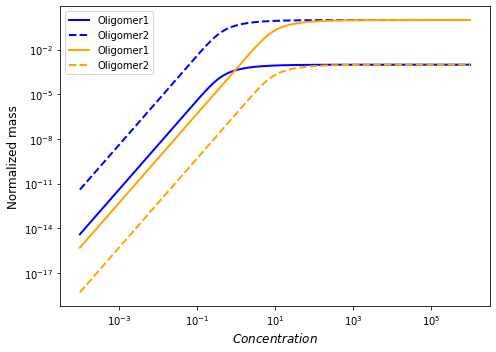

In [1]:
###### Numerical solve of normalized pre-equilibrium oligomer population ######

###### Figure 2C top row, left column

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --------------------------------------------------
# 1. Define the implicit equation
# --------------------------------------------------
def equation(x, X0, n1, n2, s1, s2):
    """
    x + n1*x*(x/s1)^(n1-1) + n2*x*(x/s2)^(n2-1) - X0 = 0
    """
    return (x+ n1 * x * (x / s1)**(n1 - 1)+ n2 * x * (x / s2)**(n2 - 1)- X0)

# --------------------------------------------------
# 2. Solve for x given X0
# --------------------------------------------------
def solve_x(X0, n1, n2, s1, s2):
    """
    Solve the equation for x in the interval [0, X0]
    """
    return brentq(equation,0.0,X0,args=(X0, n1, n2, s1, s2))

# --------------------------------------------------
# 3. Sweep X0 and compute normalized quantities
# --------------------------------------------------
def compute_fractions(X0_array, n1, n2, s1, s2):
    """
    Returns:
    f1 = n1*x *(x/s1)^(n1-1) / X0
    f2 = n2*x *(x/s2)^(n2-1) / X0
    """
    f1 = np.zeros_like(X0_array)
    f2 = np.zeros_like(X0_array)

    for i, X0 in enumerate(X0_array):
        x = solve_x(X0, n1, n2, s1, s2)

        f1[i] = n1* x * (x / s1)**(n1 - 1) / X0
        f2[i] = n2* x * (x / s2)**(n2 - 1) / X0

    return f1, f2

# --------------------------------------------------
# 4. Parameters (EDIT THESE)
# --------------------------------------------------
n1 = 4; n2 = 4; s1 = 10.0; s2 = 1.0; s3 = 20.0; s4 = 200

# X0 range
X0_array = np.logspace(-4, 6, 5000)

# --------------------------------------------------
# 5. Compute results
# --------------------------------------------------
f1, f2 = compute_fractions(X0_array, n1, n2, s1, s2)
f3, f4 = compute_fractions(X0_array, n1, n2, s3, s4)
#print(f1,f2)

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.loglog(X0_array, f1, 'b-',lw=2, label='Oligomer1')
plt.loglog(X0_array, f2, 'b--',lw=2, label='Oligomer2')
plt.loglog(X0_array, f3, color='orange',linestyle='-', lw=2, label='Oligomer1')
plt.loglog(X0_array, f4, color='orange',linestyle='--', lw=2, label='Oligomer2')
plt.xlabel(r'$Concentration$', fontsize=12)
plt.ylabel('Normalized mass', fontsize=12)
plt.legend()
plt.tight_layout()
#plt.savefig('Fig2B_oligomer_2.eps',dpi=300) ## save figure in eps format
plt.show()